In [ ]:
import datetime
import joblib
import os
import pysr
import sympy
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics as sk_metrics
import torch.nn.functional as F
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

sys.path.append('../')
from pnam.utils.plot import *
from pnam.utils.sr import *
from pnam.wrapper import PNAMBase

In [2]:
def plot_preds(X, y, preds, X_label, y_label, plot_dir=None, title=None):
    if X_label == 'Strain':
        input = X[:, 0]
        input_label = 'Strain'
    elif X_label == 'Xi':
        input = X[:, 1]
        input_label = 'Order parameter'
    if y_label == 'W':
        output = y[:, 0]
        predictions = preds[:, 0]
        output_label = 'Strain energy [MPa]'
    elif y_label == 'f':
        output = y[:, 1]
        predictions = preds[:, 1]
        output_label = 'Phase energy [MPa]'
    elif y_label == 'Stress':
        output = y[:, 2] / 1000
        predictions = preds[:, 2] / 1000
        output_label = 'Stress [GPa]'
    sort_indices = np.argsort(input)
    plt.figure(figsize=(8, 6))
    plt.plot(
        input[sort_indices],
        output[sort_indices],
        'k.',
        label='True',
        markersize=10.
    )
    plt.plot(
        input[sort_indices],
        predictions[sort_indices],
        '-r',
        label='Pred',
        linewidth=3.
    )
    plt.xlabel(input_label)
    plt.ylabel(output_label)
    plt.legend(loc='best')
    plt.grid()
    plt.tight_layout()
    if plot_dir:
        if title:
            plt.savefig(f'{plot_dir}/{y_label}_vs_{X_label}_{title}.png')
        else:
            plt.savefig(f'{plot_dir}/{y_label}_vs_{X_label}.png')
        plt.close()
    else:
        plt.show()

In [3]:
# time = datetime.datetime.now().isoformat()
time = 'phase_field_pnam8'

In [4]:
small_size = 20
large_size = 24
plt.rc('font', size=small_size)
plt.rc('axes', labelsize=large_size)

In [ ]:
data_path = '../../data/phase_field.csv'
df = pd.read_csv(data_path)

In [6]:
X_labels = ['Strain', 'Xi', 'Nabla Xi']
y_labels = ['W', 'f', 'Stress']

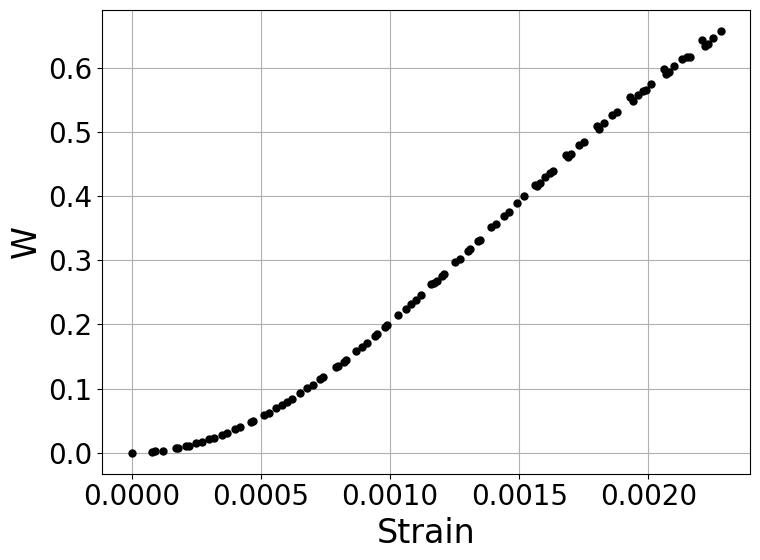

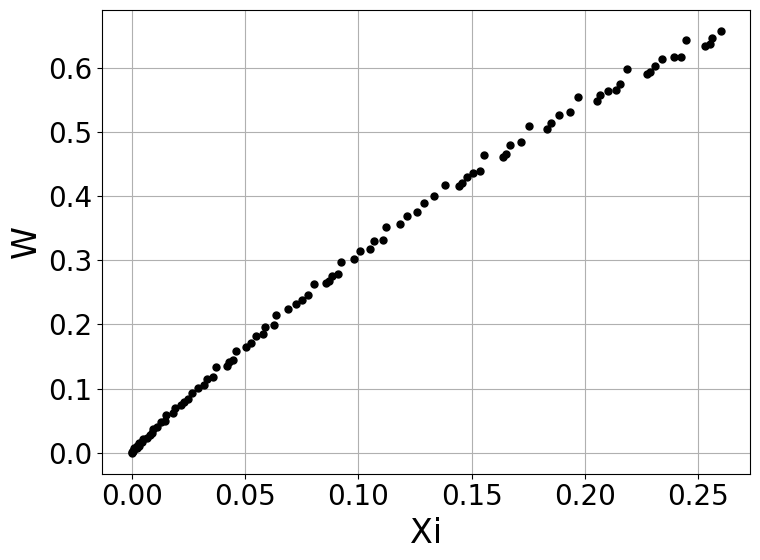

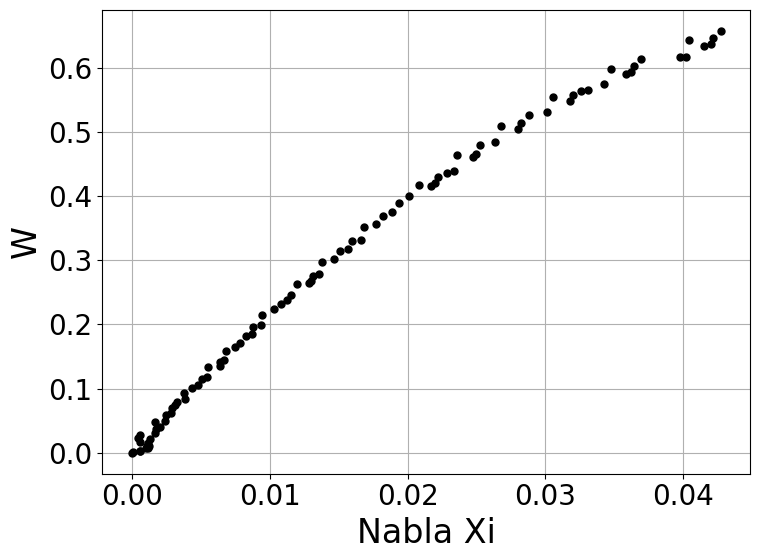

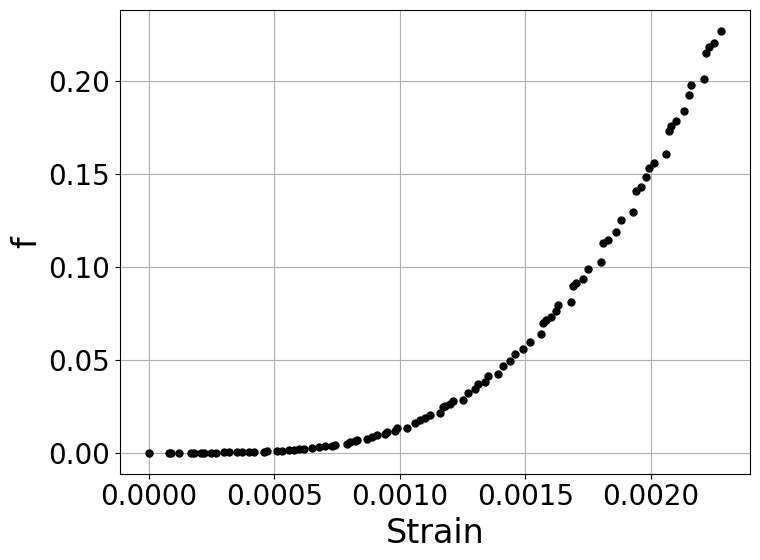

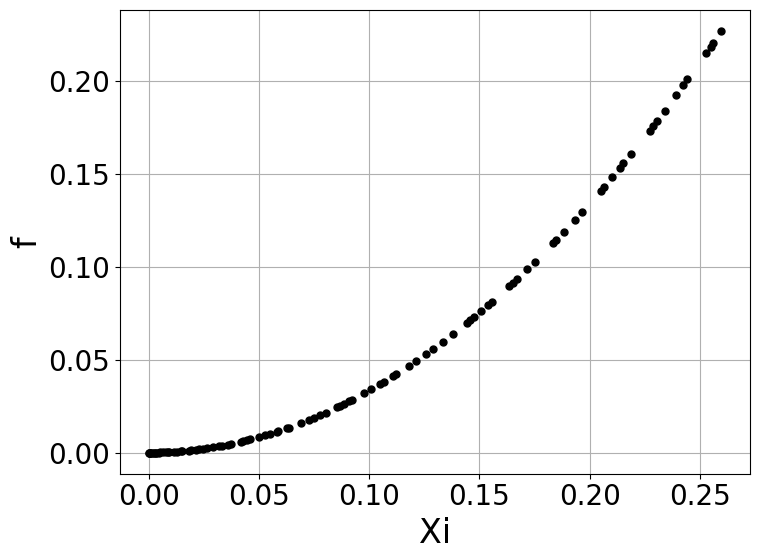

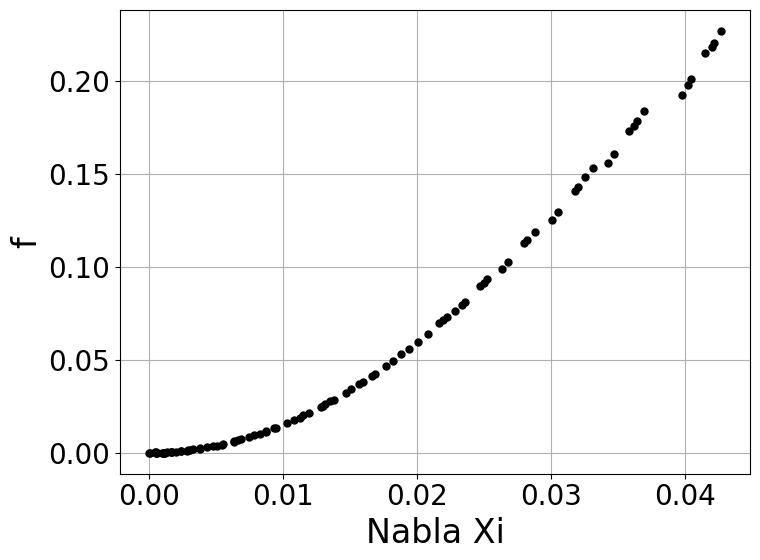

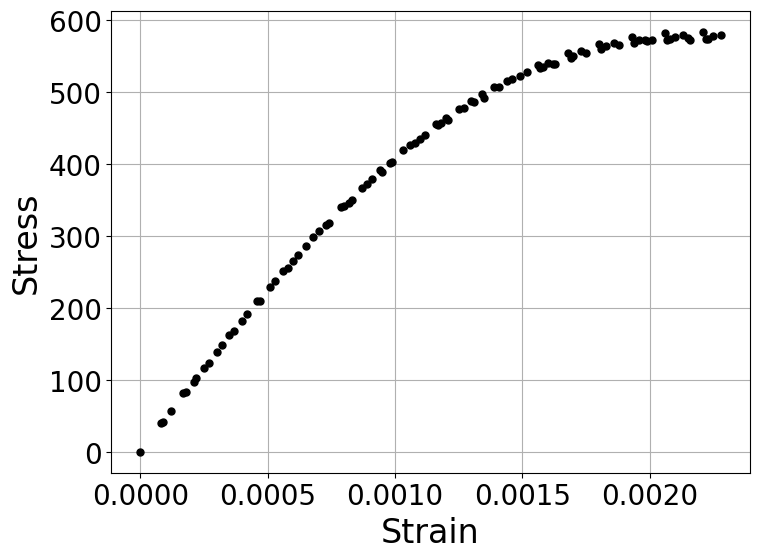

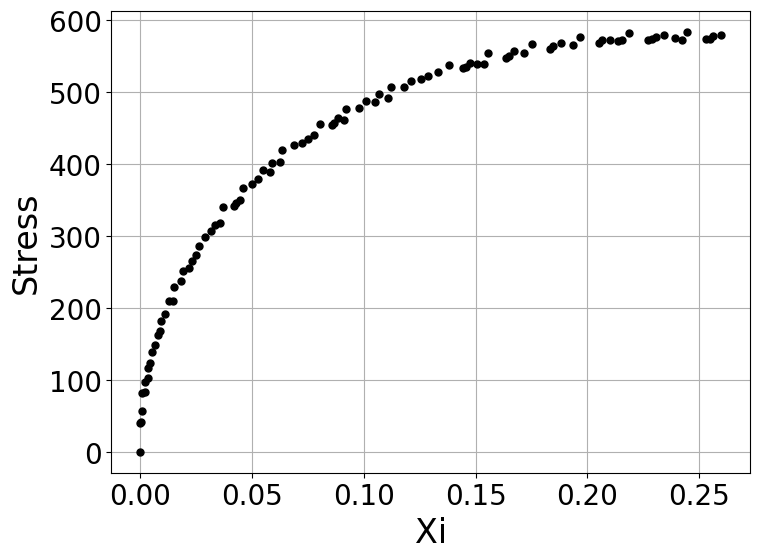

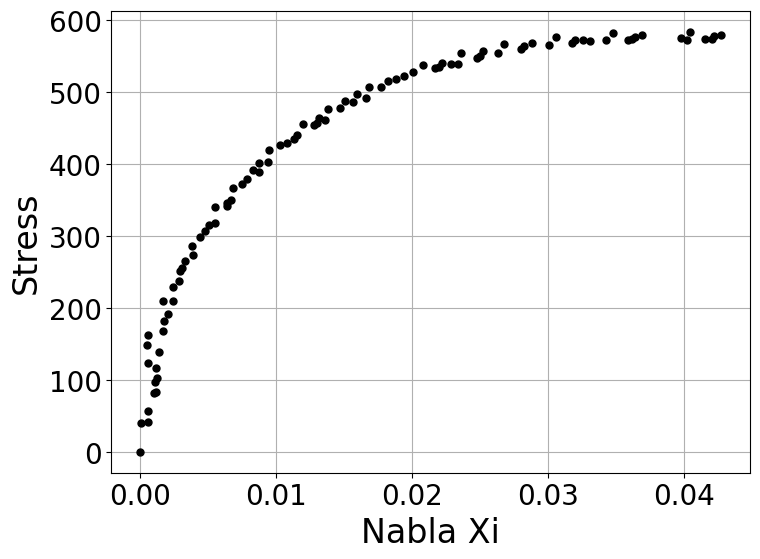

In [7]:
plot_vars(
    df[X_labels].to_numpy(),
    df[y_labels].to_numpy(),
    X_labels=X_labels,
    y_labels=y_labels
)

In [8]:
X_scaler = MinMaxScaler()
df[X_labels] = X_scaler.fit_transform(df[X_labels])
y_scaler = MinMaxScaler()
df[y_labels] = y_scaler.fit_transform(df[y_labels])

In [9]:
random_state = 42
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=random_state
)
X_train, X_test = df_train[X_labels].to_numpy(), df_test[X_labels].to_numpy()
y_train, y_test = df_train[y_labels].to_numpy(), df_test[y_labels].to_numpy()

In [10]:
pnam = True
num_inputs = X_train.shape[1]
proj_size = 8
num_networks = proj_size if proj_size > 0 else num_inputs
num_outputs = 2
metric = None
scale = True
sobolev = True

model_idx = 0
weight_thresh = 0.05
proj_mat_thresh = 0.05

sr = True
num_sr_points = 1000

In [11]:
scaler_dir = f'{time}/pnam/scaler'
os.makedirs(scaler_dir, exist_ok=True)
joblib.dump(X_scaler, f'{scaler_dir}/X_scaler.pkl')
joblib.dump(y_scaler, f'{scaler_dir}/y_scaler.pkl')

['phase_field_pnam8/pnam/scaler/y_scaler.pkl']

In [12]:
model_pnam = PNAMBase(
    random_state=random_state,
    num_learners=10,
    pnam=pnam,
    std=0.,
    proj_size=proj_size,
    hidden_sizes=[256, 256, 256],
    num_outputs=num_outputs,
    activation=F.silu,
    dropout=0.,
    feature_dropout=0.,
    device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
    regression=True,
    rot_reg=0.001,
    proj_reg=0.001,
    weight_reg=0.001,
    output_reg=0.001,
    l2_reg=0.001,
    verbose=False,
    metric=metric,
    scale=scale,
    sobolev=sobolev,
    val_split=0.2,
    n_jobs=4,
    batch_size=256,
    log_dir=f'{time}/pnam',
    lr=0.001,
    decay_step=1,
    decay_rate=0.995,
    num_epochs=5000,
    energy=True,
    patience=50
)

In [13]:
# model_pnam.fit(X_train, y_train)
model_pnam.load_checkpoints(f'{time}/pnam')

In [14]:
plot_dir = f'{time}/figures/{model_idx}'
os.makedirs(plot_dir, exist_ok=True)
print(f'Model index: {model_idx}')

Model index: 0


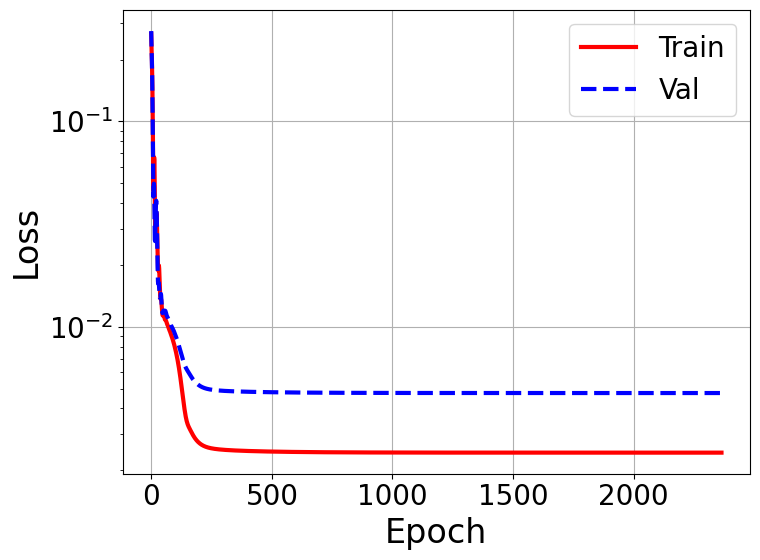

In [15]:
plot_loss_or_metric(
    time, model_idx, 'loss', semilogy=True
)

In [16]:
(
    preds_test,
    feats_out_test,
    feats_in_test,
    weight,
    bias,
    proj_mat,
    grad_in_test
) = model_pnam.predict(X_test, y_test, model_idx)

Loss: 0.0000260871


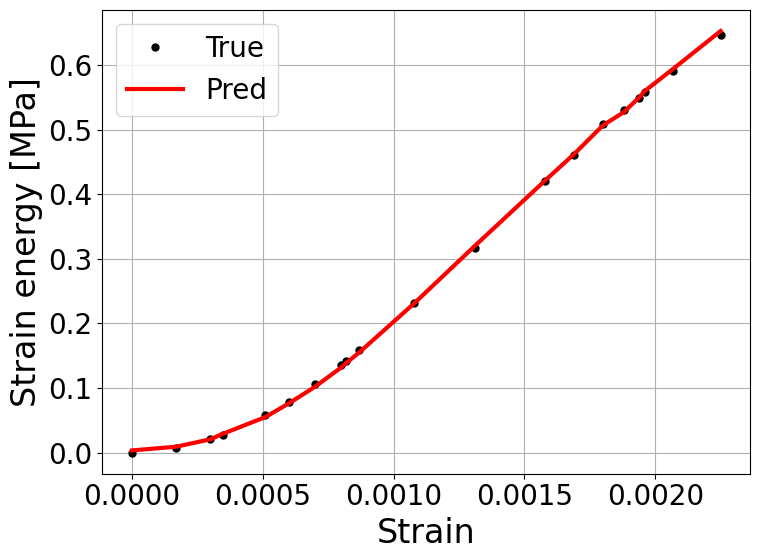

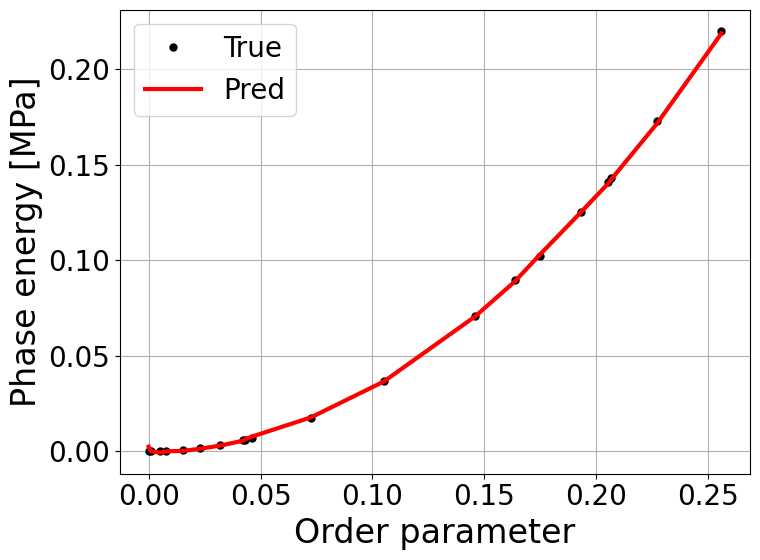

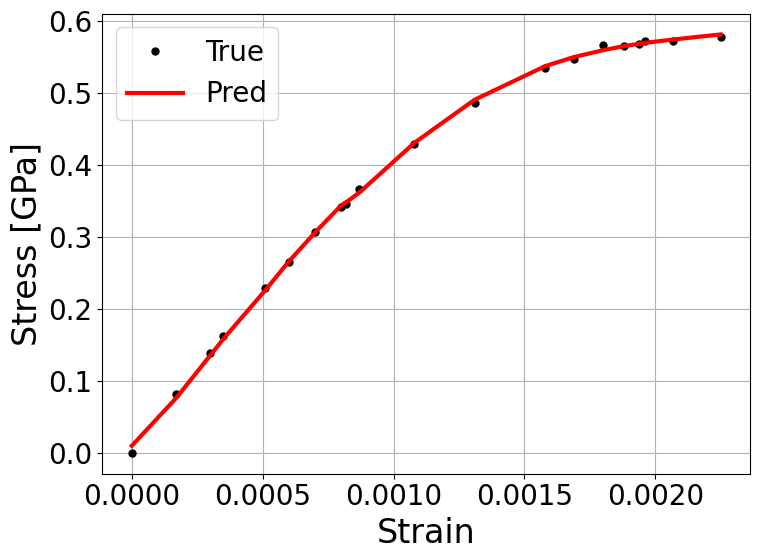

In [17]:
X = X_scaler.inverse_transform(X_test)
y = y_scaler.inverse_transform(y_test)
preds = y_scaler.inverse_transform(preds_test)
plot_preds(X, y, preds, X_label='Strain', y_label='W')
plot_preds(X, y, preds, X_label='Xi', y_label='f')
plot_preds(
    X, y, preds, X_label='Strain', y_label='Stress'
)

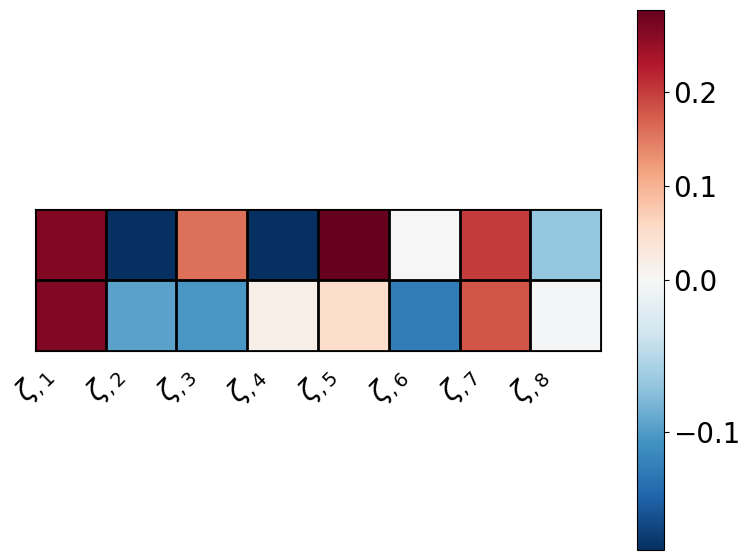

In [ ]:
plot_weight(
    weight,
    color=None,
    labels=[r'$\zeta_{,%s}$' % (i + 1) for i in range(num_networks)],
    colorbar=True
)

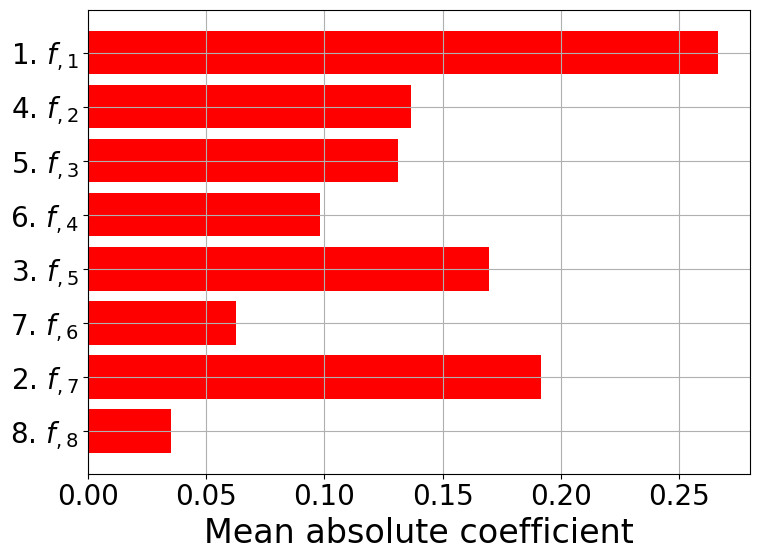

In [19]:
weight_mean = np.mean(abs(weight), axis=0)
plot_mean(
    weight_mean,
    labels=['$f_{,%s}$' % (i + 1) for i in range(num_networks)]
)

In [20]:
for i in range(proj_size):
    if weight_mean[i] == 0:
        proj_mat[i] = 0.

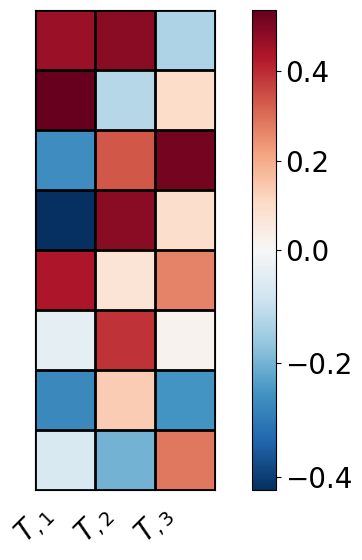

In [21]:
plot_weight(
    proj_mat,
    color=None,
    labels=['$T_{,%s}$' % (i + 1) for i in range(num_inputs)],
    colorbar=True
)

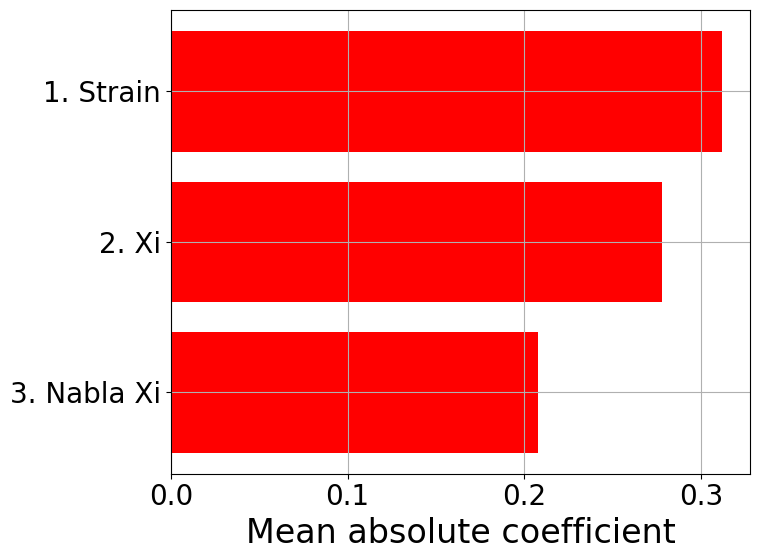

In [22]:
proj_mat_mean = np.mean(abs(proj_mat), axis=0)
plot_mean(
    proj_mat_mean,
    labels=X_labels
)

In [23]:
weight_zero = np.copy(weight)
weight_zero[abs(weight_zero) < weight_thresh] = 0.
weight_zero_mean = np.mean(abs(weight_zero), axis=0)

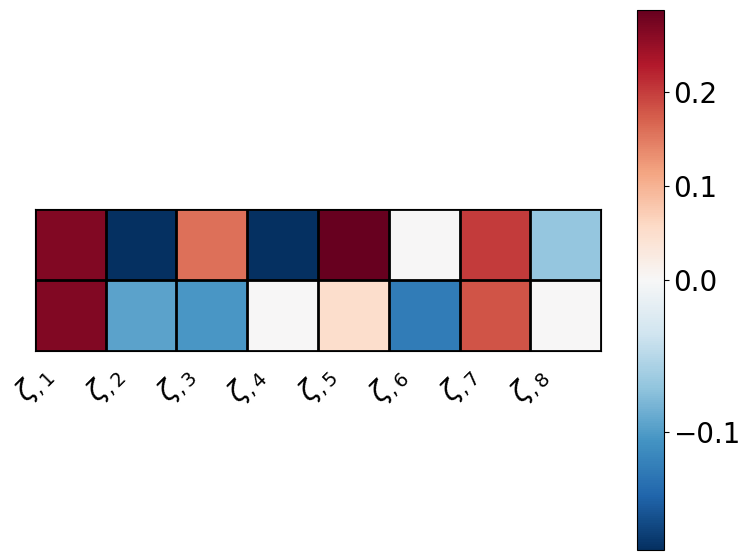

In [ ]:
plot_weight(
    weight_zero,
    color=None,
    labels=[r'$\zeta_{,%s}$' % (i + 1) for i in range(num_networks)],
    colorbar=True
)

In [25]:
proj_mat_zero = np.copy(proj_mat)
for i in range(proj_size):
    if weight_zero_mean[i] == 0:
        proj_mat_zero[i] = 0.

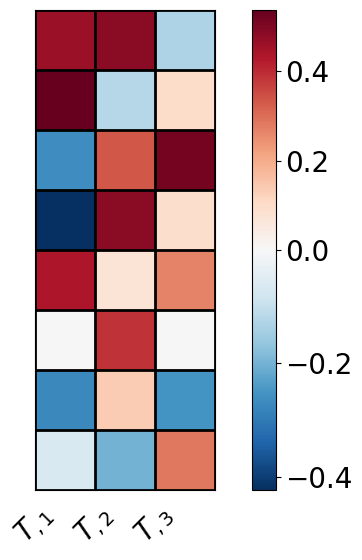

In [26]:
proj_mat_zero[abs(proj_mat_zero) < proj_mat_thresh] = 0.
plot_weight(
    proj_mat_zero,
    color=None,
    labels=['$T_{,%s}$' % (i + 1) for i in range(num_inputs)],
    colorbar=True
)

In [27]:
(
    preds_test, feats_out_test, feats_in_test, _, _, _, grad_in_test
) = model_pnam.predict(
    X_test,
    y_test,
    model_idx,
    weight_zero,
    proj_mat_zero if proj_size > 0 else None
)

Loss: 0.0000265329


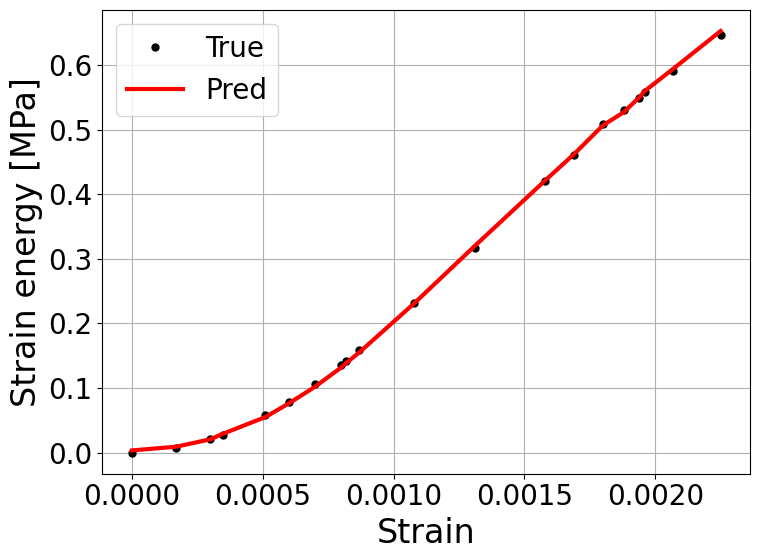

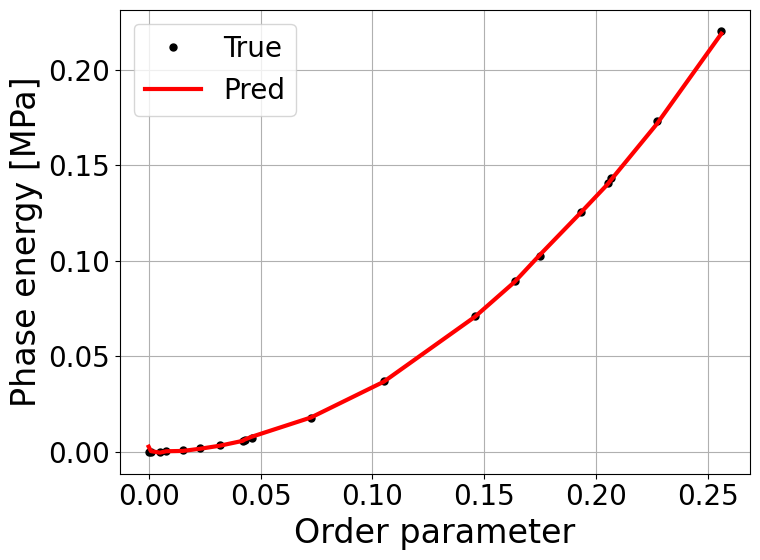

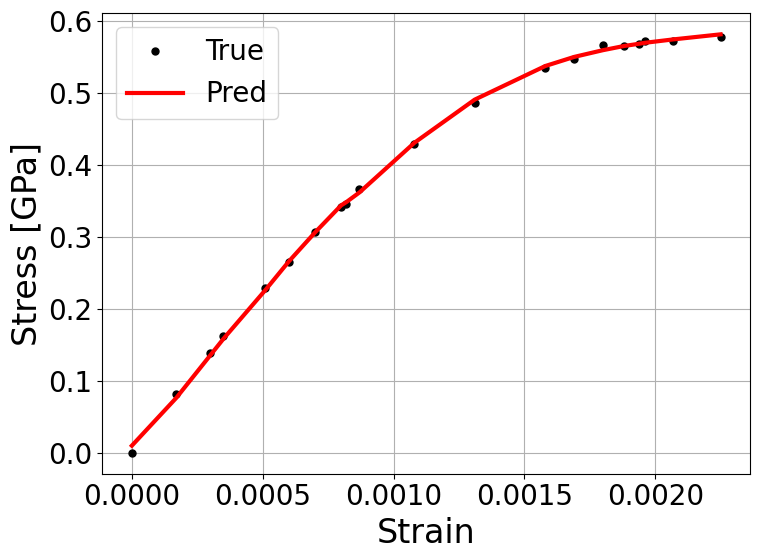

In [28]:
X = X_scaler.inverse_transform(X_test)
y = y_scaler.inverse_transform(y_test)
preds = y_scaler.inverse_transform(preds_test)
plot_preds(
    X,
    y,
    preds,
    X_label='Strain',
    y_label='W'
)
plot_preds(
    X,
    y,
    preds,
    X_label='Xi',
    y_label='f'
)
plot_preds(
    X,
    y,
    preds,
    X_label='Strain',
    y_label='Stress'
)

In [29]:
num_train_points = X_train.shape[0]
if num_train_points > num_sr_points:
    np.random.seed(random_state)
    sr_indices = np.random.choice(
        num_train_points, num_sr_points, replace=False
    )
    X_sr = X_train[sr_indices]
    y_sr = y_train[sr_indices]
else:
    X_sr = X_train
    y_sr = y_train

In [30]:
(
    preds_sr, feats_out_sr, feats_in_sr, _, _, _, grad_in_sr
) = model_pnam.predict(
    X_sr,
    y_sr,
    model_idx,
    weight_zero,
    proj_mat_zero if proj_size > 0 else None
)

Loss: 0.0000239244


In [31]:
pysr.jl.seval('''
import Pkg
Pkg.add("Zygote")
''')
pysr.jl.seval('import Zygote')

objective = '''
function my_custom_objective(
    tree, dataset::Dataset{T, L}, options
)::L where {T, L}
    pred, grad, flag = eval_diff_tree_array(
        tree, dataset.X, options, 1
    )
    !flag && return L(Inf)
    pred_diff = pred .- dataset.y
    grad_diff = grad .- dataset.weights
    return (
        sum(pred_diff.^2) + sum(grad_diff.^2)
    ) / length(pred_diff)
end
'''

   Resolving package versions...
  No Changes to `~/opt/anaconda3/julia_env/Project.toml`
  No Changes to `~/opt/anaconda3/julia_env/Manifest.toml`


In [32]:
model_sr = pysr.PySRRegressor(
    binary_operators=['+', '-', '*'],
    unary_operators=['square'],
    maxsize=30,
    niterations=10000000,
    populations=30,
    population_size=30,
    ncycles_per_iteration=500,
    elementwise_loss=None if sobolev else 'L2DistLoss()',
    loss_function=objective if sobolev else None,
    model_selection='best',
    timeout_in_seconds=60.,
    output_directory=f'{time}/sr/{model_idx}'
)

In [33]:
g_sr, gp_sr, gpp_sr = train_or_evaluate_all(
    time,
    sobolev,
    model_idx,
    weight_zero,
    feats_out_sr,
    feats_in_sr,
    grad_in_sr,
    feats_out_test,
    feats_in_test,
    grad_in_test,
    model_sr,
    train=False
)

In [34]:
eqs = pd.read_csv(f'{time}/sr/{model_idx}/equations.csv')

output: 1, z: 1
g(z):


$- z_{1}^{3} + 1.524 z_{1}^{2} + z_{1} + \left(\left(- z_{1} + \left(z_{1} - 0.028\right)^{2} + 0.75\right)^{2} - 0.102\right)^{2} - 0.269$

g(x):


$203.741 x_{1} + 1.87 x_{2} - 3.048 x_{3} + 2.9690659352591093 \cdot 10^{18} \left(- 0.005 x_{1} + \left(x_{1} + 0.009 x_{2} - 0.015 x_{3}\right)^{2}\right)^{4} + \left(x_{1} + 0.009 x_{2} - 0.015 x_{3}\right)^{2} \left(- 8457313.72 x_{1} - 77615.744 x_{2} + 126535.24 x_{3} + 21772.015\right) + 41510.213 \left(x_{1} + 0.009 x_{2} - 0.015 x_{3}\right)^{2} - 0.269$

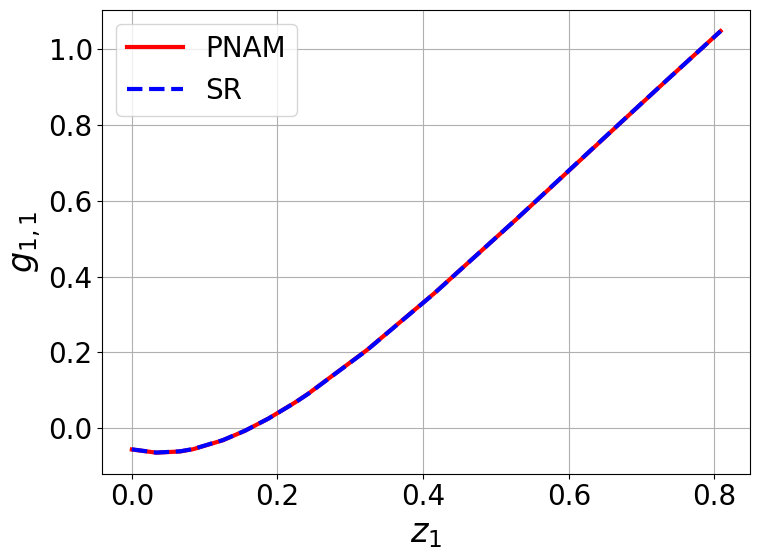

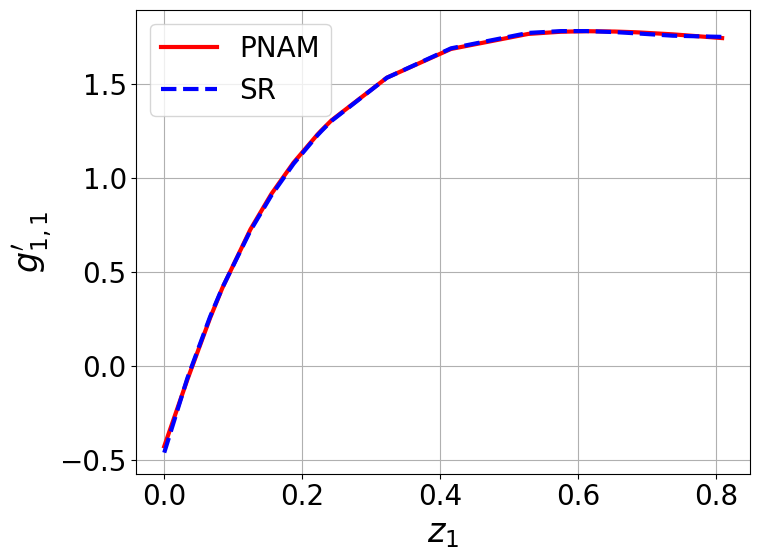

output: 1, z: 2
g(z):


$z_{2}^{3} \cdot \left(0.147 - 0.074 z_{2}\right) + 0.383 z_{2}^{2} + 0.119 z_{2} - 0.119$

g(x):


$28.168 x_{1} - 0.055 x_{2} + 0.279 x_{3} - 4164.62 \left(x_{1} - 0.002 x_{2} + 0.01 x_{3}\right)^{2} \cdot \left(235.816 x_{1} - 0.461 x_{2} + 2.333 x_{3}\right) \left(233.349 x_{1} - 0.456 x_{2} + 2.308 x_{3} - 1.963\right) + 21308.561 \left(x_{1} - 0.002 x_{2} + 0.01 x_{3}\right)^{2} - 0.119$

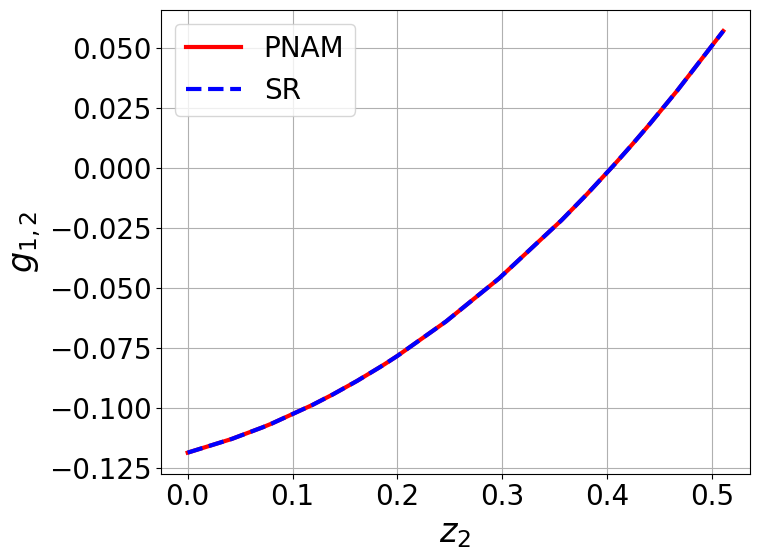

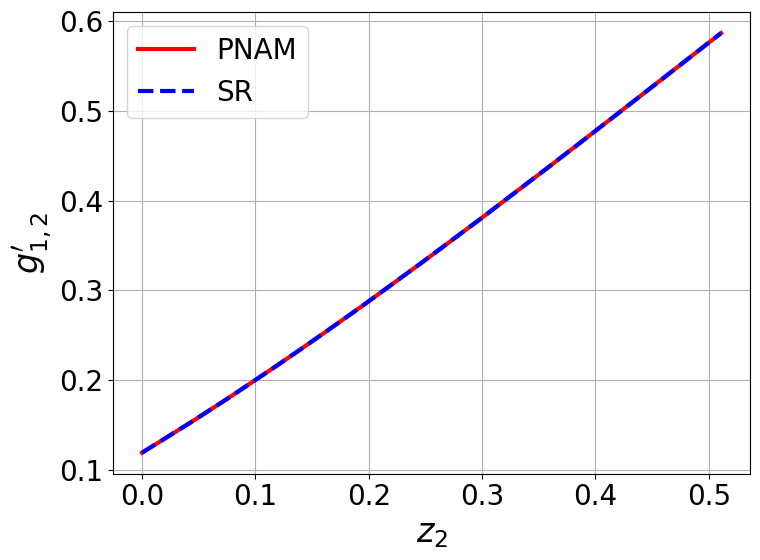

output: 1, z: 3
g(z):


$0.967 z_{3} \left(z_{3} - 1.108\right) \left(- 3.255 z_{3}^{3} + z_{3} - 1.418\right) - 2 z_{3} + 0.07$

g(x):


$229.656 x_{1} - 2.568 x_{2} - 24.178 x_{3} + 0.967 \left(\left(\left(- 4928980.615 x_{1} + 55119.587 x_{2} + 518917.569 x_{3}\right) \left(- x_{1} + 0.011 x_{2} + 0.105 x_{3}\right)^{2} + 1.418\right) \left(- 114.828 x_{1} + 1.284 x_{2} + 12.089 x_{3}\right) - 13185.508 \left(- x_{1} + 0.011 x_{2} + 0.105 x_{3}\right)^{2}\right) \left(114.828 x_{1} - 1.284 x_{2} - 12.089 x_{3} + 1.108\right) + 0.07$

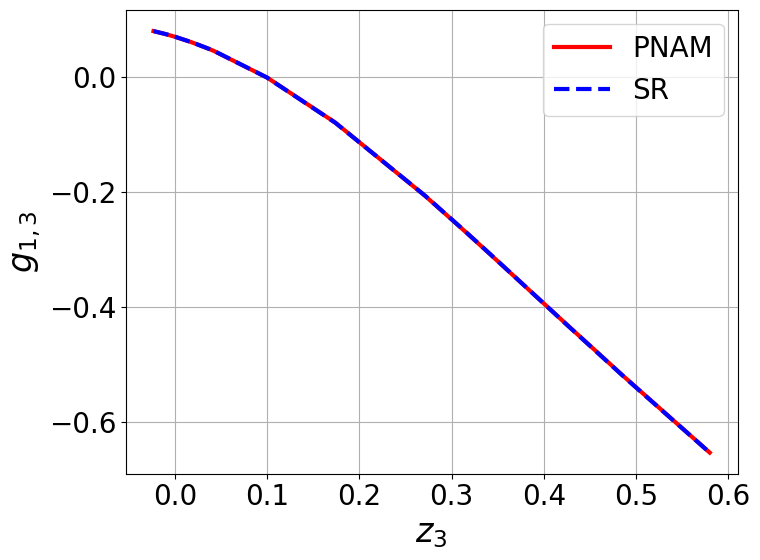

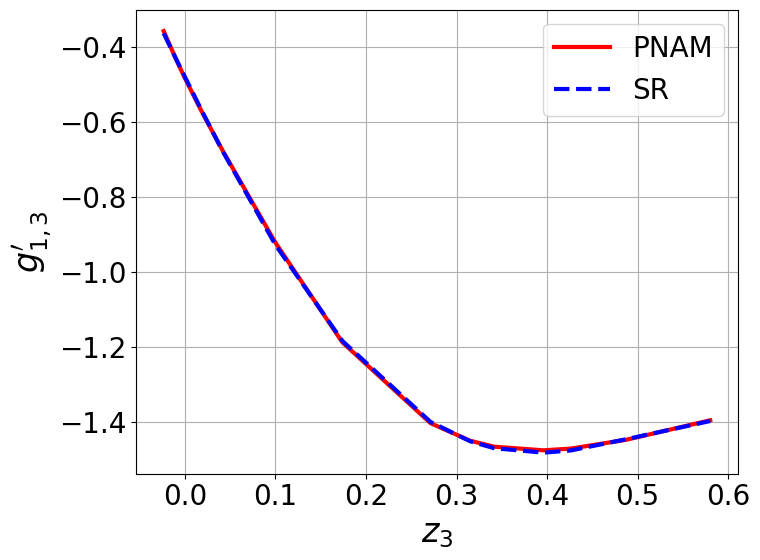

output: 1, z: 4
g(z):


$- z_{4} \cdot \left(0.009 z_{4} + 0.069\right) + 0.005$

g(x):


$- \left(- 185.754 x_{1} + 1.866 x_{2} + 2.19 x_{3}\right) \left(- 1.674 x_{1} + 0.017 x_{2} + 0.02 x_{3} + 0.069\right) + 0.005$

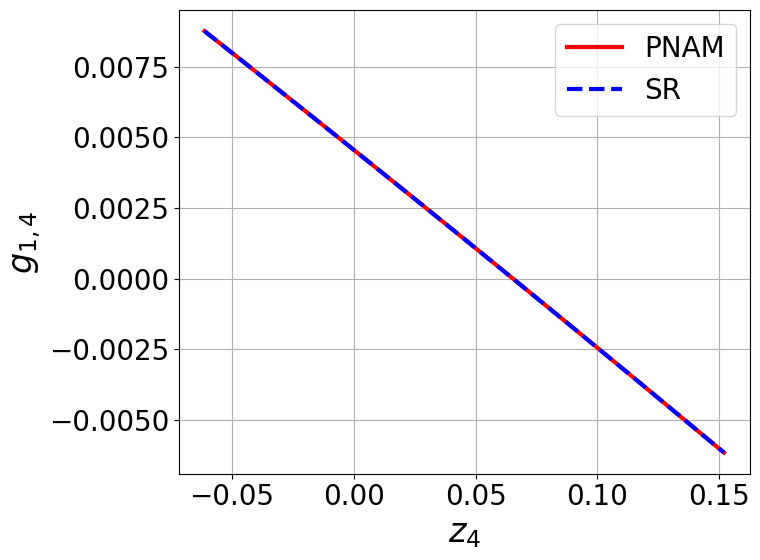

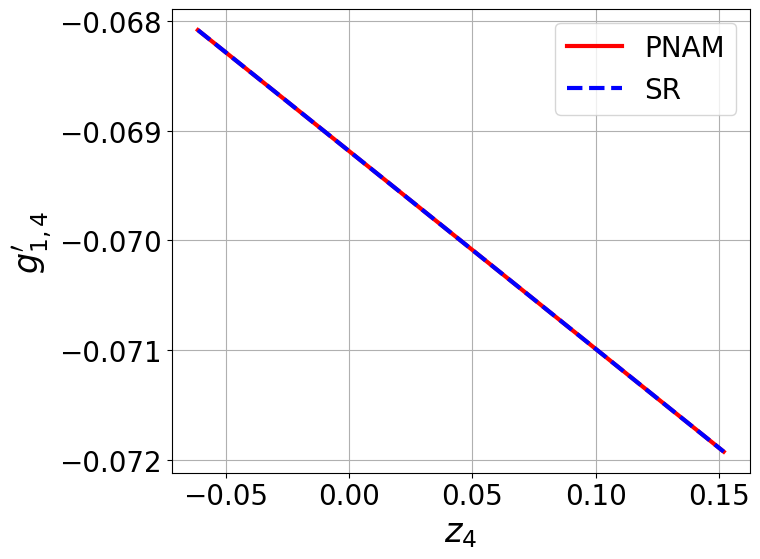

output: 1, z: 5
g(z):


$0.118 z_{5} \cdot \left(2 z_{5} + 0.217\right) \left(0.033 z_{5}^{2} \left(z_{5} + 1\right) - z_{5} + 3.239\right) - 0.116$

g(x):


$- 0.118 \cdot \left(190.698 x_{1} + 0.282 x_{2} + 6.271 x_{3}\right) \left(381.396 x_{1} + 0.564 x_{2} + 12.542 x_{3} + 0.217\right) \left(190.698 x_{1} + 0.282 x_{2} + 6.271 x_{3} - 0.033 \cdot \left(190.698 x_{1} + 0.282 x_{2} + 6.271 x_{3}\right) \left(190.698 x_{1} + 0.282 x_{2} + 6.271 x_{3} + 36365.673 \left(x_{1} + 0.001 x_{2} + 0.033 x_{3}\right)^{2}\right) - 3.239\right) - 0.116$

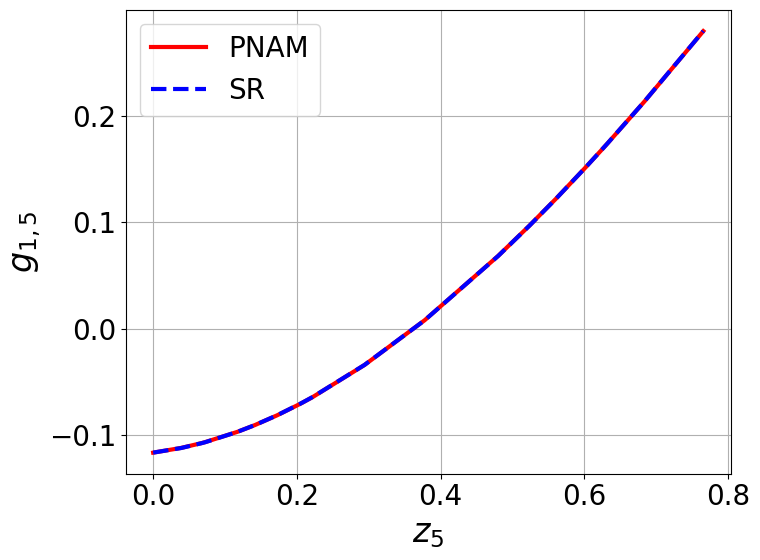

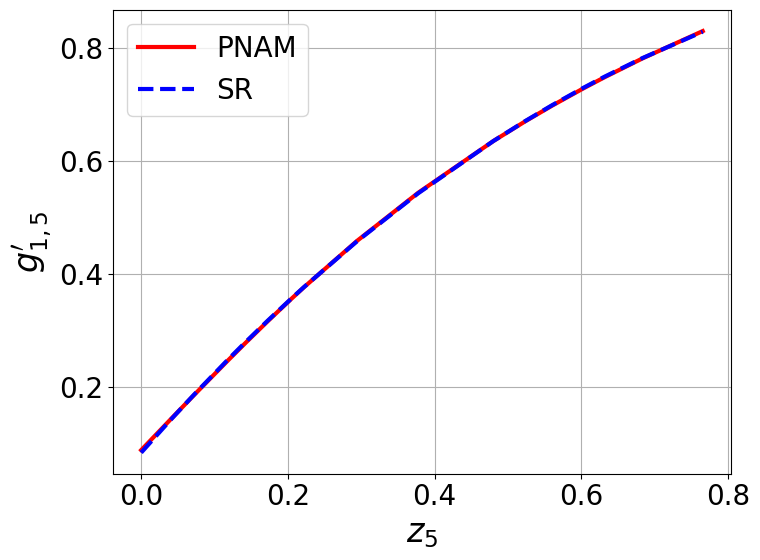

output: 1, z: 7
g(z):


$z_{7} \left(z_{7}^{2} \left(z_{7}^{10} \left(z_{7} + 0.917\right)^{2} - 0.014\right) + 0.079 z_{7} - 0.087\right) - 0.029$

g(x):


$\left(119.681 x_{1} - 0.531 x_{2} + 5.929 x_{3}\right) \left(9.447 x_{1} - 0.042 x_{2} + 0.468 x_{3} + \left(- 1.2369953564605846 \cdot 10^{29} \left(x_{1} - 0.004 x_{2} + 0.05 x_{3}\right)^{10} \left(x_{1} - 0.004 x_{2} + 0.05 x_{3} - 0.008\right)^{2} + 201.823\right) \left(x_{1} - 0.004 x_{2} + 0.05 x_{3}\right)^{2} + 0.087\right) - 0.029$

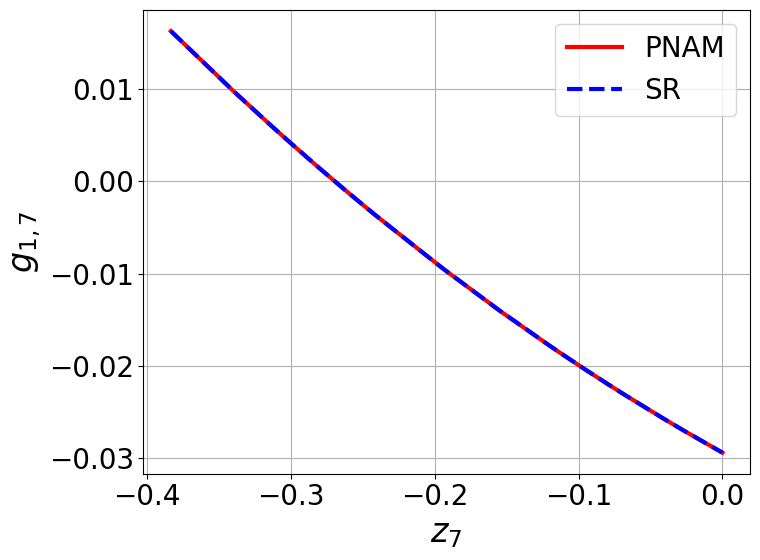

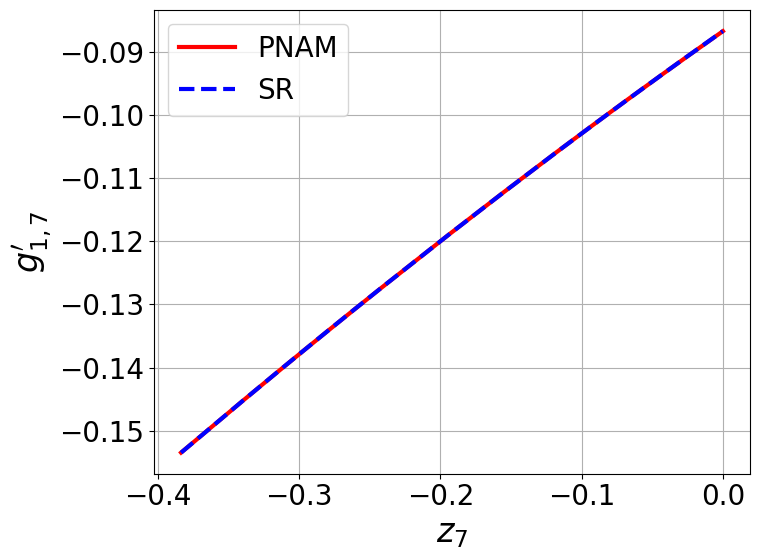

output: 1, z: 8
g(z):


$0.003 - 0.009 z_{8}$

g(x):


$0.24 x_{1} + 0.007 x_{2} - 0.057 x_{3} + \left(- 4.588 x_{1} - 0.126 x_{2} + 1.087 x_{3}\right) \left(x_{1} + 0.027 x_{2} - 0.237 x_{3}\right)^{2} + 0.13 \left(x_{1} + 0.027 x_{2} - 0.237 x_{3}\right)^{2} + 0.003$

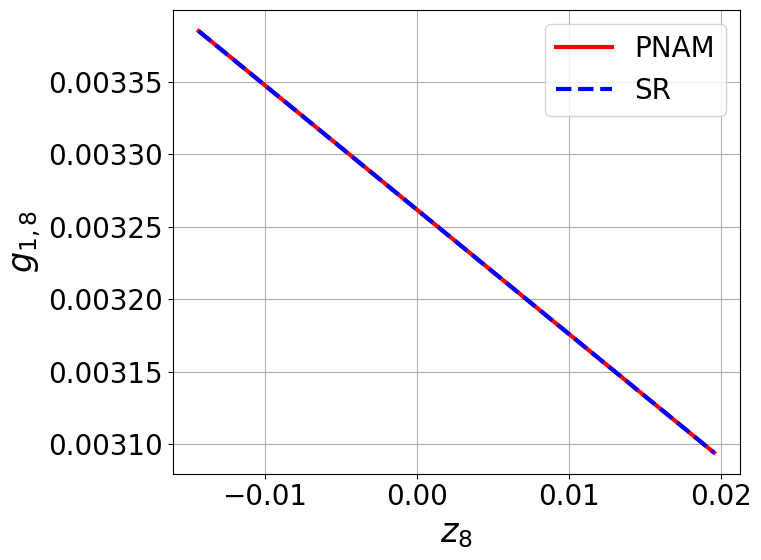

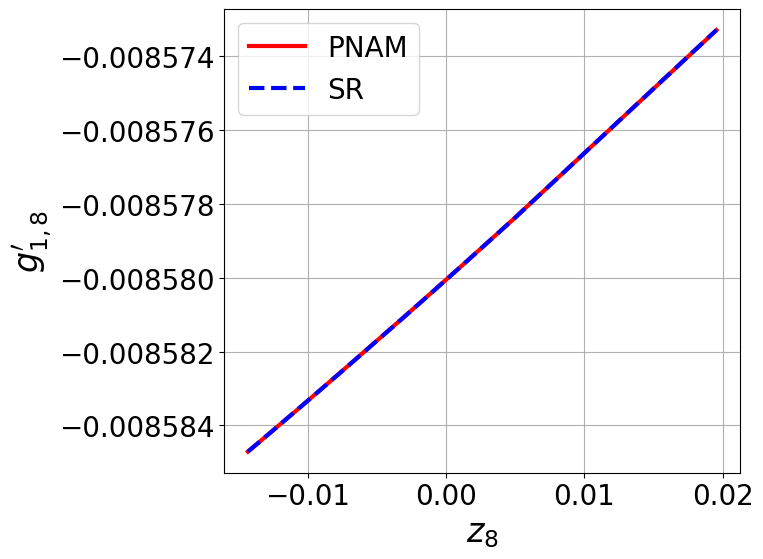

output: 2, z: 1
g(z):


$z_{1}^{2} - \left(z_{1} - 0.597\right) \left(z_{1} - 0.291\right) \left(1.378 z_{1} \left(0.786 z_{1} - 1\right)^{4} + 0.525 z_{1} - 0.074\right) - 0.093$

g(x):


$41510.213 \left(x_{1} + 0.009 x_{2} - 0.015 x_{3}\right)^{2} - \left(203.741 x_{1} + 1.87 x_{2} - 3.048 x_{3} - 0.597\right) \left(203.741 x_{1} + 1.87 x_{2} - 3.048 x_{3} - 0.291\right) \left(106.944 x_{1} + 0.981 x_{2} - 1.6 x_{3} + \left(184274471318.037 x_{1} + 1691151659.894 x_{2} - 2757047368.022 x_{3}\right) \left(x_{1} + 0.009 x_{2} - 0.015 x_{3} - 0.006\right)^{4} - 0.074\right) - 0.093$

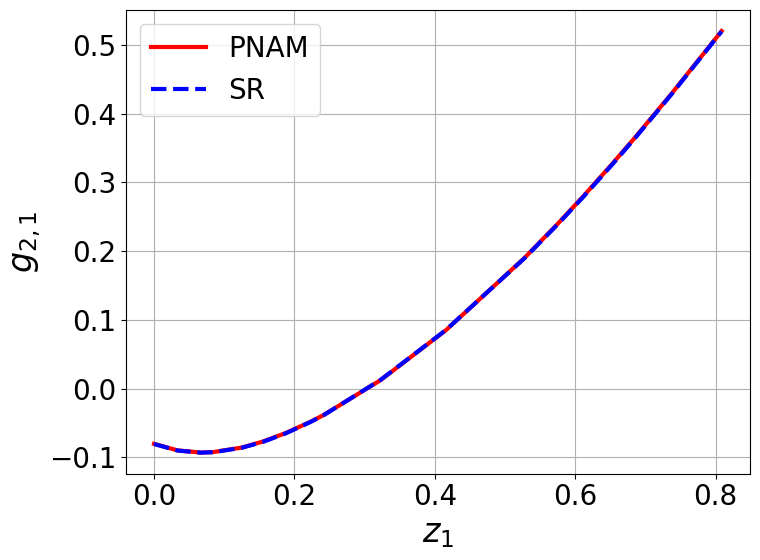

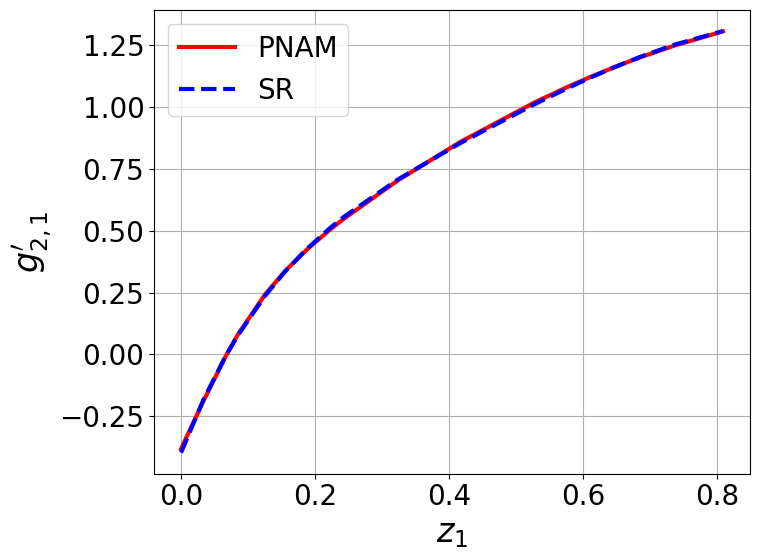

output: 2, z: 2
g(z):


$- 10.229 z_{2} \cdot \left(0.003 - 0.002 z_{2}^{2}\right) + 0.011$

g(x):


$- 10.229 \left(\left(1167.5774 x_{1} \cdot \left(235.816 x_{1} - 0.461 x_{2} + 2.333 x_{3} + 2.782\right) - 94.321\right) \left(x_{1} - 0.002 x_{2} + 0.01 x_{3}\right)^{2} + 0.003\right) \left(235.816 x_{1} - 0.461 x_{2} + 2.333 x_{3}\right) + 0.011$

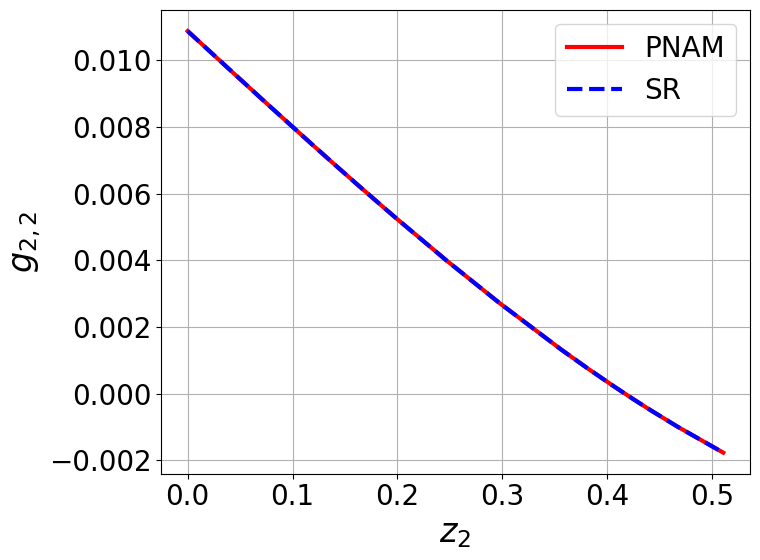

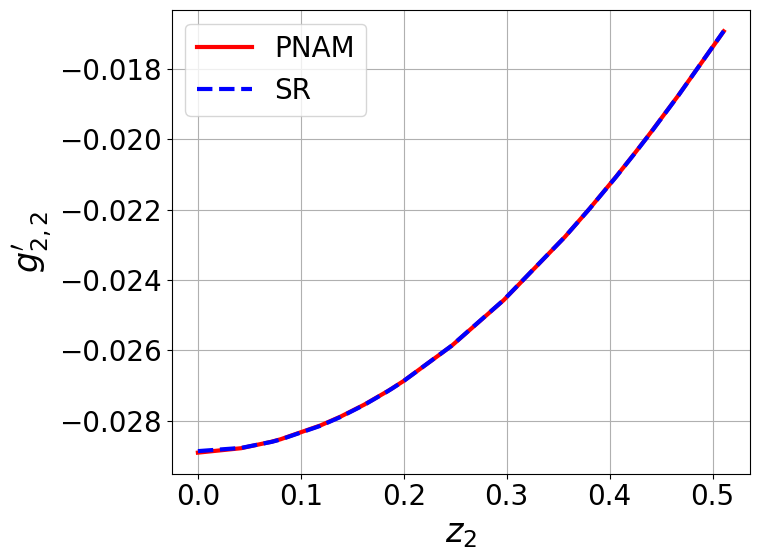

output: 2, z: 3
g(z):


$1.046 z_{3} + 2.265 \left(z_{3} - 0.403\right)^{2} \left(0.65 z_{3}^{3} - z_{3}^{2} + 0.835\right)^{2} - 0.25$

g(x):


$- 120.067 x_{1} + 1.343 x_{2} + 12.641 x_{3} + 2.890827624117476 \cdot 10^{16} \left(- x_{1} + 0.011 x_{2} + 0.105 x_{3}\right)^{4} \left(x_{1} - 0.011182 x_{2} - 0.105282 x_{3} + 0.0134039\right)^{2} \left(x_{1} - 0.011 x_{2} - 0.105 x_{3} + 0.004\right)^{2} - 0.25$

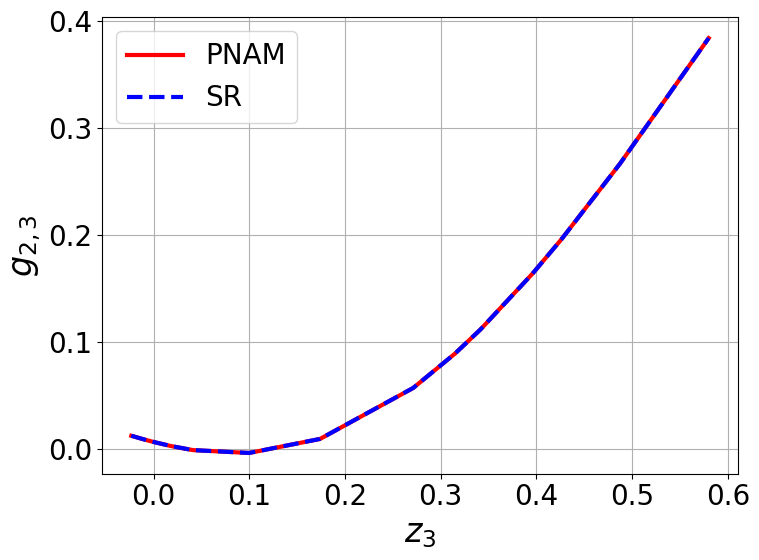

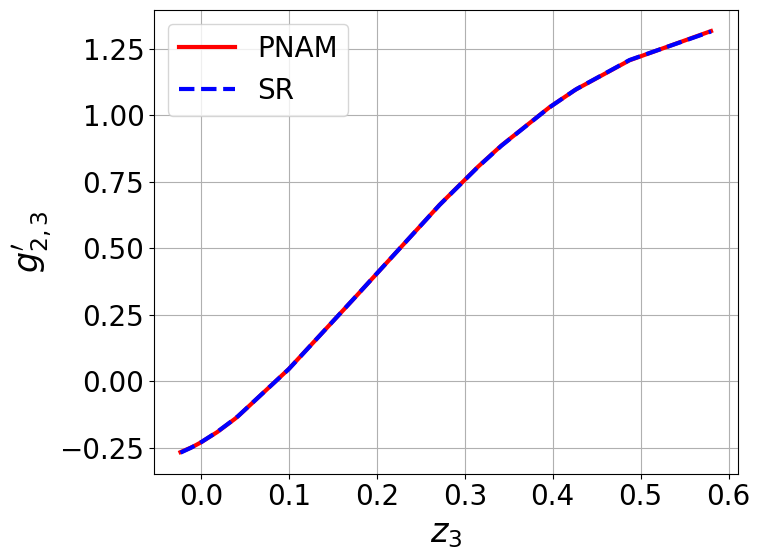

output: 2, z: 5
g(z):


$- z_{5} \left(- 0.03 z_{5} + 0.003 \left(0.772 z_{5} \left(z_{5} - 0.466\right)^{2} - z_{5} + 0.596\right)^{2} + 0.009\right) - 0.002$

g(x):


$\left(190.698 x_{1} + 0.282 x_{2} + 6.271 x_{3}\right) \left(5.757 x_{1} + 0.009 x_{2} + 0.189 x_{3} - 3830270.302 \left(0.005 x_{1} - \left(147.2 x_{1} + 0.218 x_{2} + 4.84 x_{3}\right) \left(x_{1} + 0.001 x_{2} + 0.033 x_{3} - 0.002\right)^{2}\right)^{2} - 0.009\right) - 0.002$

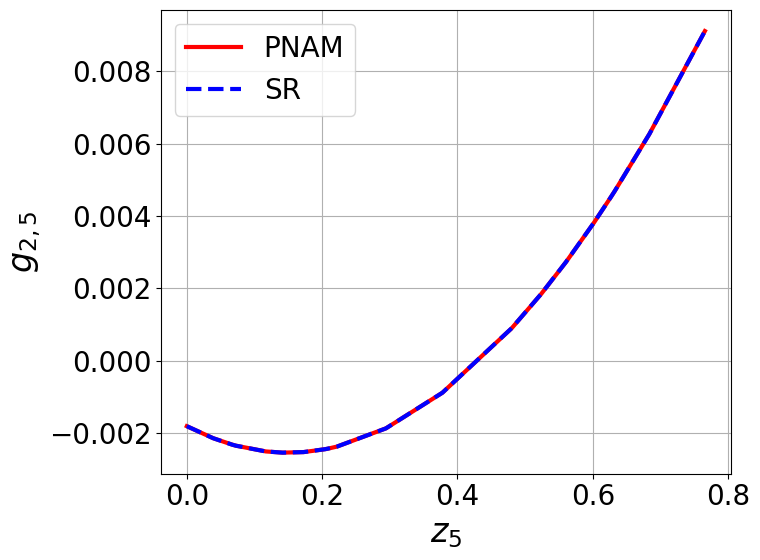

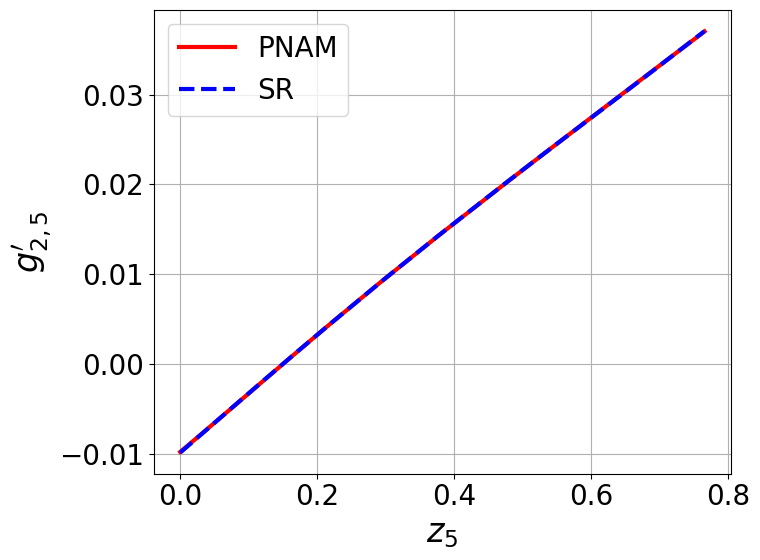

output: 2, z: 6
g(z):


$z_{6} \cdot \left(0.003 z_{6}^{2} + 0.009 z_{6} - 0.043\right) + 0.016$

g(x):


$1.503 x_{2} \cdot \left(0.006 x_{2}^{2} + 0.014 x_{2} - 0.043\right) + 0.016$

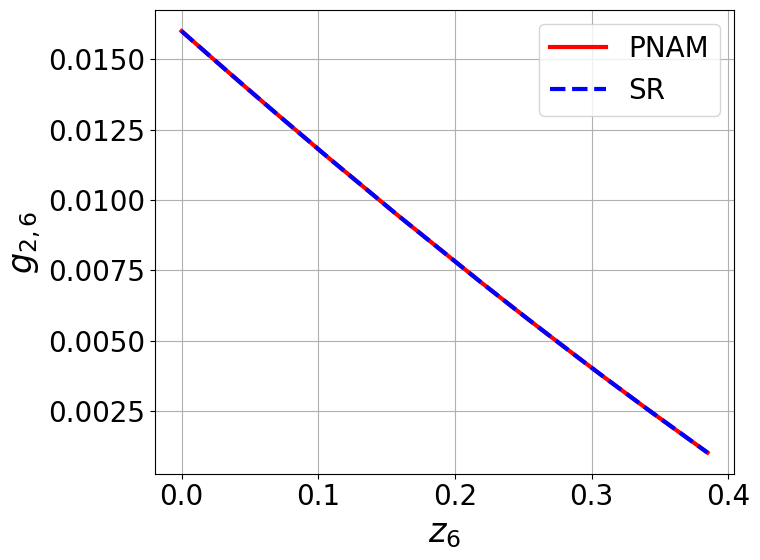

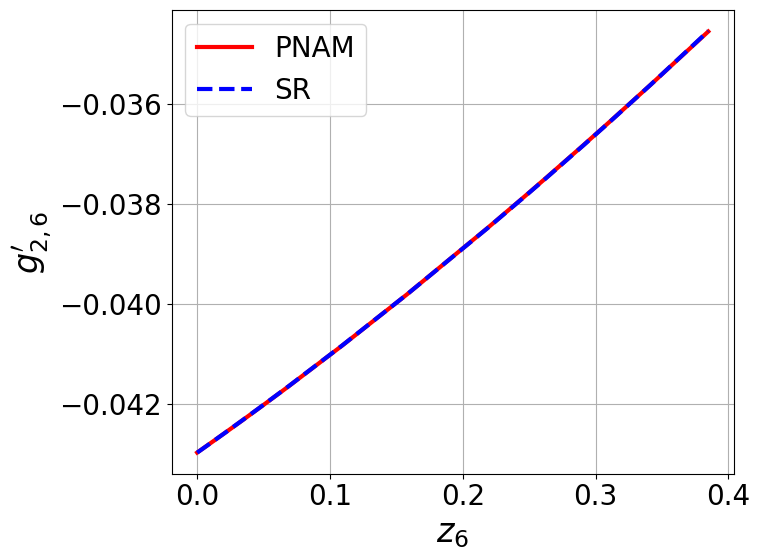

output: 2, z: 7
g(z):


$- 0.004 z_{7}^{3} + 0.009 z_{7}^{2} + 0.024 z_{7} + 0.007$

g(x):


$0.01 \cdot \left(119.681 x_{1} - 0.531 x_{2} + 5.929 x_{3} - 0.33\right) \left(119.681 x_{1} - 0.531 x_{2} + 5.929 x_{3} + \left(25.743 x_{1} - 0.114 x_{2} + 1.275 x_{3} + 0.052\right) \left(239.363 x_{1} - 1.062 x_{2} + 11.857 x_{3} - 0.147\right) - 2.122\right)$

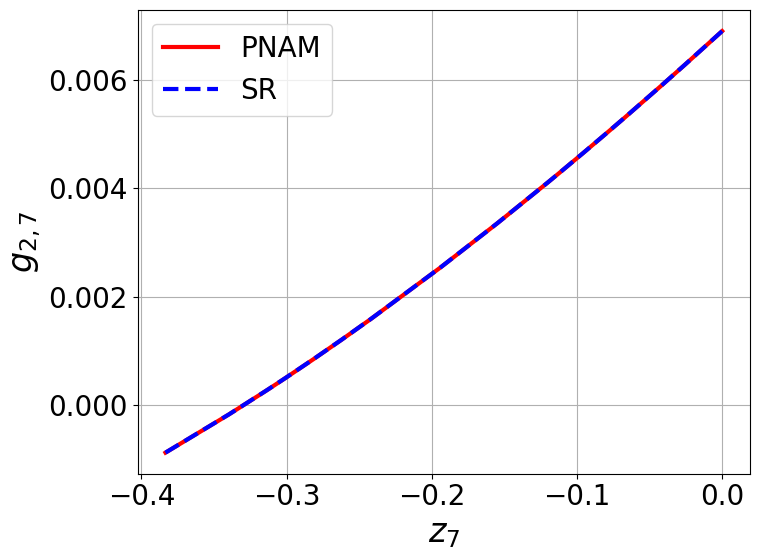

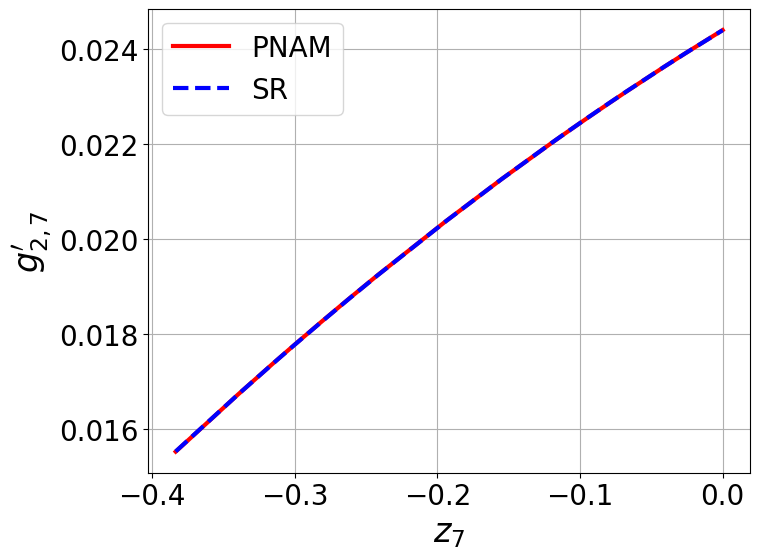

In [35]:
for i in range(num_outputs):
    for j in range(num_networks):
        if weight_zero[i, j] == 0:
            continue
            
        eq = eqs[(eqs['output'] == i + 1) & (eqs['z'] == j + 1)]
        g_feat = eq['g_sympy'].to_numpy()[0]
        g_input = construct_eq(
            proj_mat_zero if proj_size > 0 else np.eye(num_inputs),
            feat_idx=j,
            g_sympy=g_feat,
            X_scale_=X_scaler.scale_,
            X_min_=X_scaler.min_
        )
        
        g_feat = sympy.simplify(sympy.sympify(g_feat))
        g_feat = g_feat.replace(
            lambda x: isinstance(x, sympy.Float),
            lambda x: x.round(3)
        )

        g_feat = sympy.latex(g_feat)
        g_input = sympy.latex(g_input)
        print(f'output: {i + 1}, z: {j + 1}')
        print('g(z):')
        display(Markdown(f'${g_feat}$'))
        print('g(x):')
        display(Markdown(f'${g_input}$'))
            
        plot_g_vs_z(
            feats_in_test,
            feats_out_test,
            g_sr=g_sr if sr else None,
            out_idx=i,
            feat_idx=j,
            prime=False
        )
        plot_g_vs_z(
            feats_in_test,
            grad_in_test,
            g_sr=gp_sr if sr else None,
            out_idx=i,
            feat_idx=j,
            prime=True
        )

In [37]:
preds = np.zeros_like(y_test)
preds[:, :-1] = (
    np.sum(g_sr, axis=-1) + bias - y_scaler.min_[:-1]
) / y_scaler.scale_[:-1]
jac = gp_sr @ proj_mat_zero if proj_size > 0 else gp_sr
preds_grad = jac[:, :, 0] * X_scaler.scale_[0] / y_scaler.scale_[:-1]
preds[:, 2] = np.sum(preds_grad, axis=1)
loss = sk_metrics.mean_squared_error(
    y_test, preds * y_scaler.scale_ + y_scaler.min_
)
print(f'Loss: {loss:.10f}')

Loss: 0.0000225111


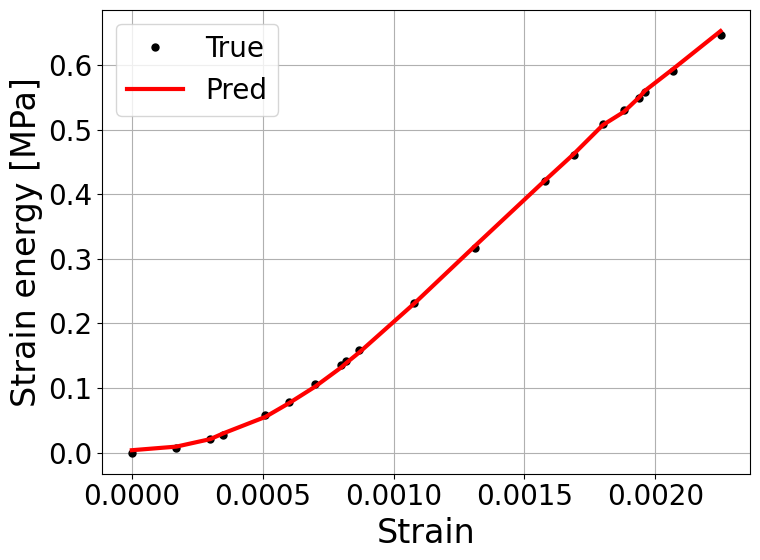

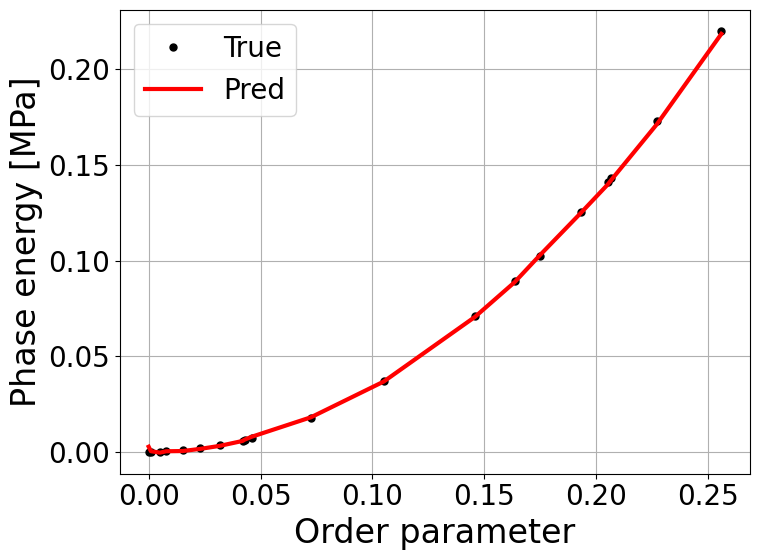

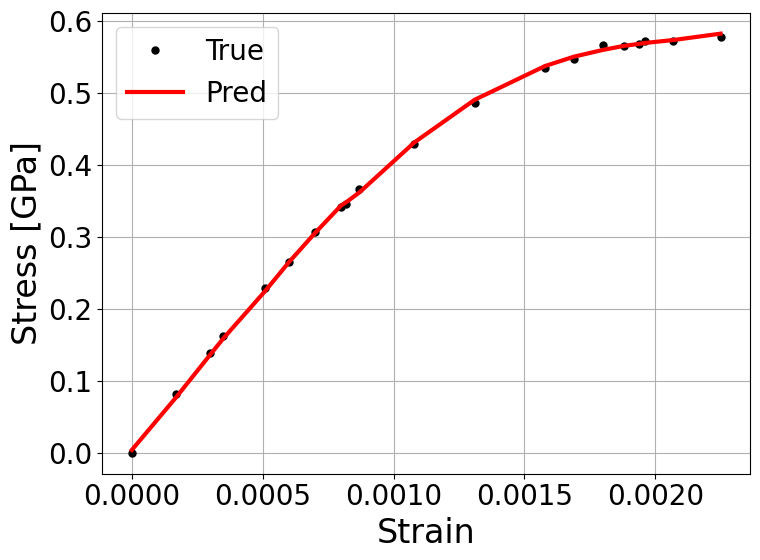

In [38]:
X = X_scaler.inverse_transform(X_test)
y = y_scaler.inverse_transform(y_test)
plot_preds(
    X,
    y,
    preds,
    X_label='Strain',
    y_label='W'
)
plot_preds(
    X,
    y,
    preds,
    X_label='Xi',
    y_label='f'
)
plot_preds(
    X,
    y,
    preds,
    X_label='Strain',
    y_label='Stress'
)